In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/factory_sensor_simulator_2040.csv")
display(df)

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,3,False,0,820.0,False,NaN,NaN,NaN,NaN,0
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,1,False,4,34.0,False,NaN,NaN,NaN,NaN,0
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,2,False,4,815.0,False,NaN,NaN,NaN,NaN,0
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,2,True,0,99.0,False,NaN,NaN,NaN,NaN,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  500000 non-null  object 
 1   Machine_Type                500000 non-null  object 
 2   Installation_Year           500000 non-null  int64  
 3   Operational_Hours           500000 non-null  int64  
 4   Temperature_C               500000 non-null  float64
 5   Vibration_mms               500000 non-null  float64
 6   Sound_dB                    500000 non-null  float64
 7   Oil_Level_pct               500000 non-null  float64
 8   Coolant_Level_pct           500000 non-null  float64
 9   Power_Consumption_kW        500000 non-null  float64
 10  Last_Maintenance_Days_Ago   500000 non-null  int64  
 11  Maintenance_History_Count   500000 non-null  int64  
 12  Failure_History_Count       500000 non-null  int64  
 13  AI_Supervision

In [4]:
null = df.isnull().sum()
print(f"Missing values:\n\n{null}")

Missing values:

Machine_ID                         0
Machine_Type                       0
Installation_Year                  0
Operational_Hours                  0
Temperature_C                      0
Vibration_mms                      0
Sound_dB                           0
Oil_Level_pct                      0
Coolant_Level_pct                  0
Power_Consumption_kW               0
Last_Maintenance_Days_Ago          0
Maintenance_History_Count          0
Failure_History_Count              0
AI_Supervision                     0
Error_Codes_Last_30_Days           0
Remaining_Useful_Life_days         0
Failure_Within_7_Days              0
Laser_Intensity               484844
Hydraulic_Pressure_bar        469660
Coolant_Flow_L_min            454376
Heat_Index                    454786
AI_Override_Events                 0
dtype: int64


In [5]:
duplicates = df.duplicated().sum()
print(f"Duplicated data: {duplicates}")

Duplicated data: 0


In [6]:
print(f"Number of unique values per column")
df.nunique()

Number of unique values per column


Machine_ID                    500000
Machine_Type                      33
Installation_Year                 41
Operational_Hours              99328
Temperature_C                   9878
Vibration_mms                   3604
Sound_dB                        6806
Oil_Level_pct                   9275
Coolant_Level_pct               9984
Power_Consumption_kW           43440
Last_Maintenance_Days_Ago        366
Maintenance_History_Count         19
Failure_History_Count             13
AI_Supervision                     2
Error_Codes_Last_30_Days          14
Remaining_Useful_Life_days      1106
Failure_Within_7_Days              2
Laser_Intensity                 4247
Hydraulic_Pressure_bar          6766
Coolant_Flow_L_min              5172
Heat_Index                     17980
AI_Override_Events                12
dtype: int64

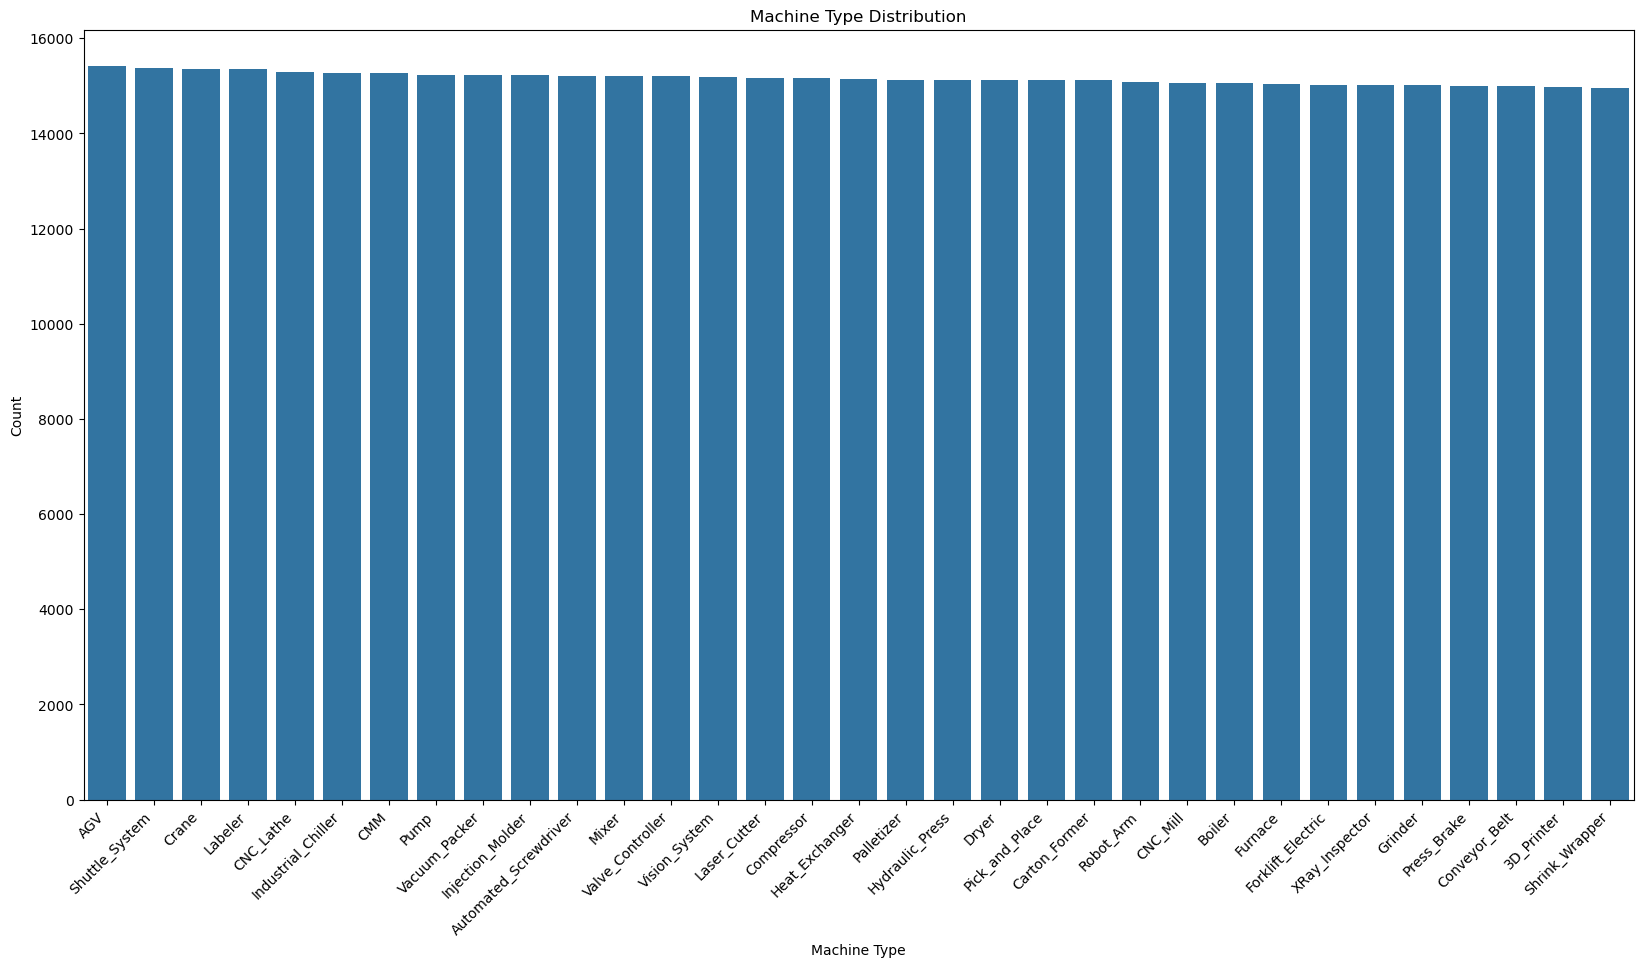

In [7]:
plt.figure(figsize=(20,10))
ax = sns.countplot(x='Machine_Type', data=df, order=df['Machine_Type'].value_counts().index)
plt.title('Machine Type Distribution')
plt.xlabel('Machine Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.ylabel('Count')
plt.show()

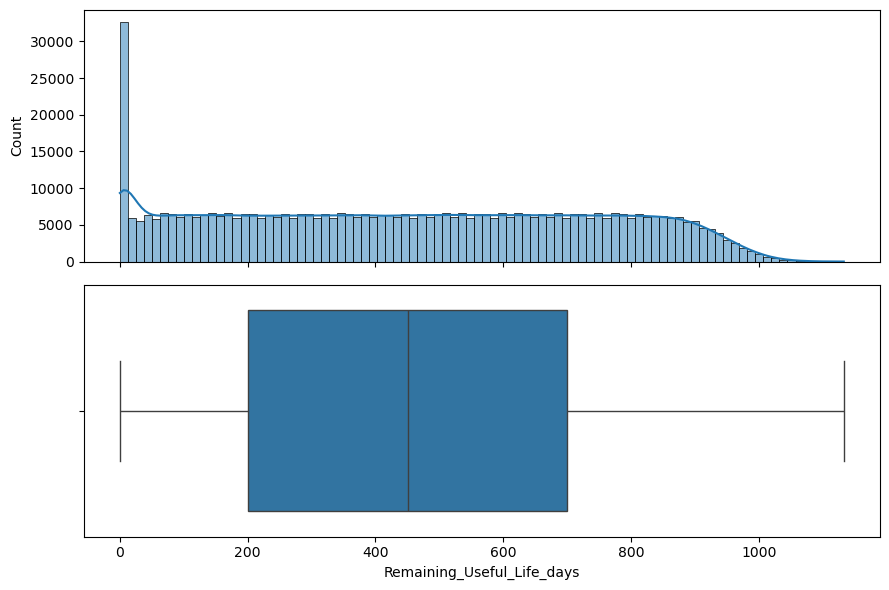

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Histogram with KDE
sns.histplot(data=df, x='Remaining_Useful_Life_days', kde=True, ax=axes[0])

# Boxplot
sns.boxplot(data=df, x='Remaining_Useful_Life_days', ax=axes[1])

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
df_train, df_test = train_test_split(df, test_size=0.99, random_state=42)

print(df_train.shape)
print(df_test.shape)     

(5000, 22)
(495000, 22)


In [11]:
import smogn

In [12]:
df_smogn = smogn.smoter(
    
    data=df_train.reset_index(), 
    y='Remaining_Useful_Life_days',
    
    #rel_thres = 0.7,
    #samp_method = 'extreme',
    rel_method = 'auto',
    rel_xtrm_type = 'low',
    rel_coef = 0.4
)


r_index: 100%|##########| 1100/1100 [00:07<00:00, 146.07it/s]


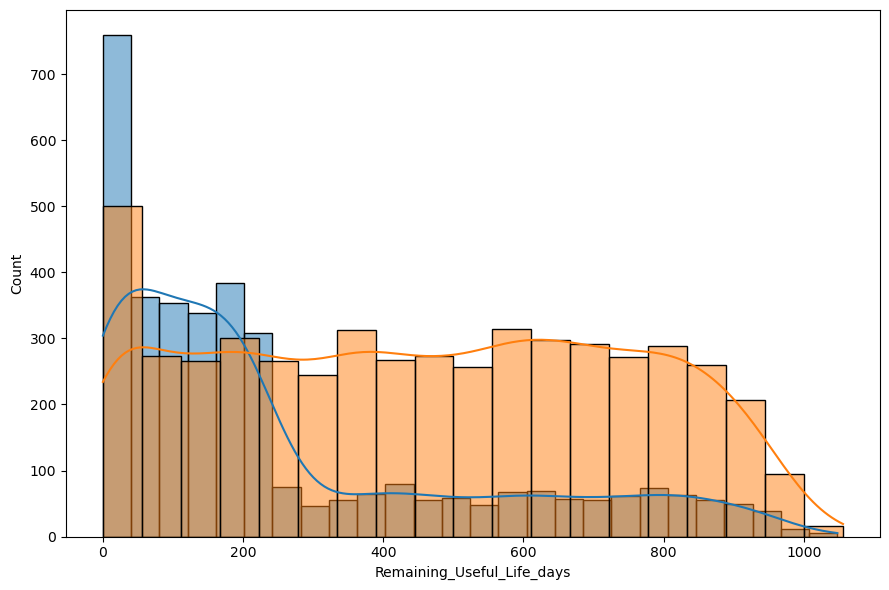

In [13]:
fig, axes = plt.subplots(figsize=(9, 6))

sns.histplot(data=df_smogn, x='Remaining_Useful_Life_days', kde=True, ax=axes)
sns.histplot(data=df_train, x='Remaining_Useful_Life_days', kde=True, ax=axes)

plt.tight_layout()
plt.show()

In [14]:
X_train = df_smogn.drop(columns=['Machine_ID', 'index', 'Failure_Within_7_Days', 'Remaining_Useful_Life_days'])
y_train = df_smogn[['Remaining_Useful_Life_days']]

In [15]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [16]:
X_test = df_test.sample(n=3000, random_state=42)

In [17]:
y_test = X_test[['Remaining_Useful_Life_days']]

In [18]:
X_test.drop(columns=['Machine_ID', 'Failure_Within_7_Days', 'Remaining_Useful_Life_days', 'Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index'], inplace=True)

In [19]:
X_train = pd.get_dummies(X_train, columns=['Machine_Type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Machine_Type'], drop_first=True)

In [20]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3600, 46)
(3600, 1)
(3000, 46)
(3000, 1)


In [21]:
model1 = XGBRegressor(max_depth=6)
model1.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [22]:
y_pred = model1.predict(X_test)

# Print metrics
print("\nMSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 2891.816918238875
R2 Score: 0.9654628038406372


In [23]:
model2 = LGBMRegressor(max_depth=6)
model2.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000892 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2177
[LightGBM] [Info] Number of data points in the train set: 3600, number of used features: 46
[LightGBM] [Info] Start training from score 251.234463
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMRegressor(max_depth=6)

In [24]:
y_pred = model2.predict(X_test)

# Print metrics
print("\nMSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 2617.6492206383064
R2 Score: 0.9687372304081107


In [25]:
y_pred = pd.DataFrame(data=y_pred)

In [26]:
# Ensure X_test columns match X_train (important after get_dummies)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# y_pred currently a numpy array from model.predict(X_test)
# Convert to a DataFrame with a descriptive column name
y_pred_df = pd.DataFrame({'y_pred': np.ravel(y_pred)})

# Ensure y_test is a single-column DataFrame/Series and reset its index so rows align
y_test_df = y_test.reset_index(drop=True).copy()
# If its column name is not 'y_true', rename for clarity
if y_test_df.columns[0] != 'y_true':
    y_test_df.columns = ['y_true']

# Combine side-by-side (one row per sample)
results = pd.concat([y_test_df, y_pred_df.reset_index(drop=True)], axis=1)

display(results)
print("results.shape:", results.shape)

,y_true,y_pred
0,27.0,124.006463
1,465.0,419.401386
2,560.0,496.331838
3,0.0,2.957377
4,641.0,678.830150
...,...,...
2995,0.0,4.038128
2996,603.0,623.724971
2997,1.0,41.584584
2998,291.0,279.383792


results.shape: (3000, 2)


In [27]:
# Build y_true series from y_test (handles DataFrame or Series)
if isinstance(y_test, pd.DataFrame):
    if 'Remaining_Useful_Life_days' in y_test.columns:
        y_true = y_test['Remaining_Useful_Life_days'].reset_index(drop=True).copy()
    else:
        y_true = y_test.iloc[:, 0].reset_index(drop=True).copy()
else:
    y_true = pd.Series(y_test).reset_index(drop=True).copy()

y_true = pd.to_numeric(y_true, errors='coerce')  # coerce non-numeric -> NaN

# Build y_pred series from y_pred (handles numpy array, DataFrame, Series)
if isinstance(y_pred, pd.DataFrame):
    y_pred_ser = pd.Series(y_pred.iloc[:, 0].values, name='y_pred').reset_index(drop=True)
else:
    y_pred_ser = pd.Series(np.ravel(y_pred), name='y_pred').reset_index(drop=True)

y_pred_ser = pd.to_numeric(y_pred_ser, errors='coerce')

# Align lengths if they differ
if len(y_true) != len(y_pred_ser):
    print(f"Warning: length mismatch before filtering (y_true={len(y_true)}, y_pred={len(y_pred_ser)}). Trimming to min length.")
    min_len = min(len(y_true), len(y_pred_ser))
    y_true = y_true.iloc[:min_len].reset_index(drop=True)
    y_pred_ser = y_pred_ser.iloc[:min_len].reset_index(drop=True)

# Filter: keep only rows with ground-truth > 100 days
mask = y_true > 100  # strict more-than
y_true_f = y_true[mask].reset_index(drop=True)
y_pred_f = y_pred_ser[mask].reset_index(drop=True)

if len(y_true_f) == 0:
    print("No rows with y_true > 100 found. R2 cannot be computed.")
else:
    r2 = r2_score(y_true_f, y_pred_f)
    print(f"R2 score for rows with y_true > 100: {r2:.6f}")

R2 score for rows with y_true > 100: 0.954316


In [28]:
# Build y_true series from y_test (handles DataFrame or Series)
if isinstance(y_test, pd.DataFrame):
    if 'Remaining_Useful_Life_days' in y_test.columns:
        y_true = y_test['Remaining_Useful_Life_days'].reset_index(drop=True).copy()
    else:
        y_true = y_test.iloc[:, 0].reset_index(drop=True).copy()
else:
    y_true = pd.Series(y_test).reset_index(drop=True).copy()

y_true = pd.to_numeric(y_true, errors='coerce')  # coerce non-numeric -> NaN

# Build y_pred series from y_pred (handles numpy array, DataFrame, Series)
if isinstance(y_pred, pd.DataFrame):
    y_pred_ser = pd.Series(y_pred.iloc[:, 0].values, name='y_pred').reset_index(drop=True)
else:
    y_pred_ser = pd.Series(np.ravel(y_pred), name='y_pred').reset_index(drop=True)

y_pred_ser = pd.to_numeric(y_pred_ser, errors='coerce')

# Align lengths if they differ
if len(y_true) != len(y_pred_ser):
    print(f"Warning: length mismatch before filtering (y_true={len(y_true)}, y_pred={len(y_pred_ser)}). Trimming to min length.")
    min_len = min(len(y_true), len(y_pred_ser))
    y_true = y_true.iloc[:min_len].reset_index(drop=True)
    y_pred_ser = y_pred_ser.iloc[:min_len].reset_index(drop=True)

# Filter: keep only rows with ground-truth < 100 days
mask = y_true < 100  # strict less-than
y_true_f = y_true[mask].reset_index(drop=True)
y_pred_f = y_pred_ser[mask].reset_index(drop=True)

if len(y_true_f) == 0:
    print("No rows with y_true < 100 found. R2 cannot be computed.")
else:
    r2 = r2_score(y_true_f, y_pred_f)
    print(f"R2 score for rows with y_true < 100: {r2:.6f}")

R2 score for rows with y_true < 100: -0.376020


In [29]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

print(df_train.shape)
print(df_test.shape)     

(350000, 22)
(150000, 22)


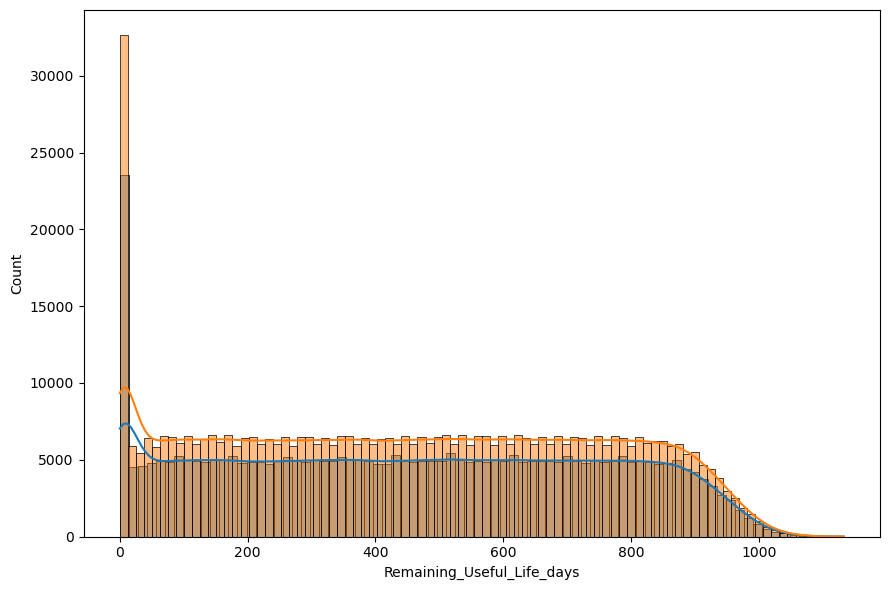

In [30]:
fig, axes = plt.subplots(figsize=(9, 6))

sns.histplot(data=df_train, x='Remaining_Useful_Life_days', kde=True, ax=axes)
sns.histplot(data=df, x='Remaining_Useful_Life_days', kde=True, ax=axes)

plt.tight_layout()
plt.show()

In [31]:
X_train = df_train.drop(columns=['Machine_ID', 'Failure_Within_7_Days', 'Remaining_Useful_Life_days', 'Coolant_Flow_L_min', 'Heat_Index', 'Hydraulic_Pressure_bar', 'Laser_Intensity'])
y_train = df_train[['Remaining_Useful_Life_days']]

In [32]:
X_test = df_test.sample(n=3000, random_state=42)
y_test = X_test[['Remaining_Useful_Life_days']]

In [33]:
X_test.drop(columns=['Machine_ID', 'Failure_Within_7_Days', 'Remaining_Useful_Life_days', 'Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index'], inplace=True)

In [34]:
X_train = pd.get_dummies(X_train, columns=['Machine_Type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Machine_Type'], drop_first=True)

In [35]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(350000, 46)
(350000, 1)
(3000, 46)
(3000, 1)


In [36]:
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

# Print metrics
print("\nMSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 2350.081767266711
R2 Score: 0.9716857671737671


In [37]:
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)

# Print metrics
print("\nMSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031026 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2196
[LightGBM] [Info] Number of data points in the train set: 350000, number of used features: 46
[LightGBM] [Info] Start training from score 452.580534
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

MSE: 2325.390599220306
R2 Score: 0.9719832549251602


In [38]:
# Ensure X_test columns match X_train (important after get_dummies)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# y_pred currently a numpy array from model.predict(X_test)
# Convert to a DataFrame with a descriptive column name
y_pred_df = pd.DataFrame({'y_pred': np.ravel(y_pred)})

# Ensure y_test is a single-column DataFrame/Series and reset its index so rows align
y_test_df = y_test.reset_index(drop=True).copy()
# If its column name is not 'y_true', rename for clarity
if y_test_df.columns[0] != 'y_true':
    y_test_df.columns = ['y_true']

# Combine side-by-side (one row per sample)
results = pd.concat([y_test_df, y_pred_df.reset_index(drop=True)], axis=1)

display(results)
print("results.shape:", results.shape)

,y_true,y_pred
0,0.0,98.292972
1,708.0,680.743731
2,53.0,85.804624
3,1011.0,952.335763
4,265.0,352.533320
...,...,...
2995,0.0,31.040407
2996,183.0,158.061321
2997,1011.0,953.248272
2998,684.0,769.860180


results.shape: (3000, 2)


In [39]:
# Build y_true series from y_test (handles DataFrame or Series)
if isinstance(y_test, pd.DataFrame):
    if 'Remaining_Useful_Life_days' in y_test.columns:
        y_true = y_test['Remaining_Useful_Life_days'].reset_index(drop=True).copy()
    else:
        y_true = y_test.iloc[:, 0].reset_index(drop=True).copy()
else:
    y_true = pd.Series(y_test).reset_index(drop=True).copy()

y_true = pd.to_numeric(y_true, errors='coerce')  # coerce non-numeric -> NaN

# Build y_pred series from y_pred (handles numpy array, DataFrame, Series)
if isinstance(y_pred, pd.DataFrame):
    y_pred_ser = pd.Series(y_pred.iloc[:, 0].values, name='y_pred').reset_index(drop=True)
else:
    y_pred_ser = pd.Series(np.ravel(y_pred), name='y_pred').reset_index(drop=True)

y_pred_ser = pd.to_numeric(y_pred_ser, errors='coerce')

# Align lengths if they differ
if len(y_true) != len(y_pred_ser):
    print(f"Warning: length mismatch before filtering (y_true={len(y_true)}, y_pred={len(y_pred_ser)}). Trimming to min length.")
    min_len = min(len(y_true), len(y_pred_ser))
    y_true = y_true.iloc[:min_len].reset_index(drop=True)
    y_pred_ser = y_pred_ser.iloc[:min_len].reset_index(drop=True)

# Filter: keep only rows with ground-truth > 100 days
mask = y_true > 100  # strict more-than
y_true_f = y_true[mask].reset_index(drop=True)
y_pred_f = y_pred_ser[mask].reset_index(drop=True)

if len(y_true_f) == 0:
    print("No rows with y_true > 100 found. R2 cannot be computed.")
else:
    r2 = r2_score(y_true_f, y_pred_f)
    print(f"R2 score for rows with y_true > 100: {r2:.6f}")

R2 score for rows with y_true > 100: 0.959525


In [40]:
# Build y_true series from y_test (handles DataFrame or Series)
if isinstance(y_test, pd.DataFrame):
    if 'Remaining_Useful_Life_days' in y_test.columns:
        y_true = y_test['Remaining_Useful_Life_days'].reset_index(drop=True).copy()
    else:
        y_true = y_test.iloc[:, 0].reset_index(drop=True).copy()
else:
    y_true = pd.Series(y_test).reset_index(drop=True).copy()

y_true = pd.to_numeric(y_true, errors='coerce')  # coerce non-numeric -> NaN

# Build y_pred series from y_pred (handles numpy array, DataFrame, Series)
if isinstance(y_pred, pd.DataFrame):
    y_pred_ser = pd.Series(y_pred.iloc[:, 0].values, name='y_pred').reset_index(drop=True)
else:
    y_pred_ser = pd.Series(np.ravel(y_pred), name='y_pred').reset_index(drop=True)

y_pred_ser = pd.to_numeric(y_pred_ser, errors='coerce')

# Align lengths if they differ
if len(y_true) != len(y_pred_ser):
    print(f"Warning: length mismatch before filtering (y_true={len(y_true)}, y_pred={len(y_pred_ser)}). Trimming to min length.")
    min_len = min(len(y_true), len(y_pred_ser))
    y_true = y_true.iloc[:min_len].reset_index(drop=True)
    y_pred_ser = y_pred_ser.iloc[:min_len].reset_index(drop=True)

# Filter: keep only rows with ground-truth < 100 days
mask = y_true < 100  # strict less-than
y_true_f = y_true[mask].reset_index(drop=True)
y_pred_f = y_pred_ser[mask].reset_index(drop=True)

if len(y_true_f) == 0:
    print("No rows with y_true < 100 found. R2 cannot be computed.")
else:
    r2 = r2_score(y_true_f, y_pred_f)
    print(f"R2 score for rows with y_true < 100: {r2:.6f}")

R2 score for rows with y_true < 100: -0.170983
